# HAR TFM

In [248]:
import pandas as pd
import numpy as np
import json

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

ruta_archivo_csv = "Datos Combinados/data/DatosCombinados_Total.csv"

df = pd.read_csv(ruta_archivo_csv)
print(df)


                 timestamp   Bpressure        Gx        Gz  Lilluminance  \
0      2023-06-11 09:54:24  915.505005 -0.111403  0.260450       19857.0   
1      2023-06-11 09:54:24  915.512451 -0.521053 -0.362767           NaN   
2      2023-06-11 09:54:25  915.538757 -0.099644 -0.428662           NaN   
3      2023-06-11 09:54:25  915.567505 -0.148436 -0.541592           NaN   
4      2023-06-11 09:54:25  915.552490 -0.027564 -0.430266           NaN   
...                    ...         ...       ...       ...           ...   
26885                  NaN         NaN       NaN       NaN         119.0   
26886  2023-06-08 07:24:58         NaN       NaN       NaN        1068.0   
26887  2023-06-08 07:25:03         NaN       NaN       NaN         253.0   
26888  2023-06-08 07:28:31         NaN       NaN       NaN         240.0   
26889                  NaN         NaN       NaN       NaN       12163.0   

              My        Ax         Mz        Az          deviceId  activity  \
0     -4

In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26890 entries, 0 to 26889
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     26860 non-null  object 
 1   Bpressure     6552 non-null   float64
 2   Gx            24271 non-null  float64
 3   Gz            24271 non-null  float64
 4   Lilluminance  6691 non-null   float64
 5   My            23692 non-null  float64
 6   Ax            25815 non-null  float64
 7   Mz            23692 non-null  float64
 8   Az            25815 non-null  float64
 9   deviceId      22049 non-null  object 
 10  activity      26890 non-null  int64  
 11  Ay            25815 non-null  float64
 12  counter       26890 non-null  int64  
 13  Gy            24271 non-null  float64
 14  Mx            23692 non-null  float64
dtypes: float64(11), int64(2), object(2)
memory usage: 3.1+ MB


## Añadir otro dataset

In [250]:
data = pd.DataFrame()
for i in range(10):
    df_tmp = pd.read_csv('data/Participant_' + str(i+1) + '.csv', header=1)
    data = pd.concat([data, df_tmp])

# View top 5 rows of dataframe
data.head()

,time_stamp,Ax,Ay,Az,Lx,Ly,Lz,Gx,Gy,Gz,...,Lx.4,Ly.4,Lz.4,Gx.4,Gy.4,Gz.4,Mx.4,My.4,Mz.4,Unnamed: 69
0,1.390000e+12,-1.81150,-14.873,-1.34840,-1.26910,-5.1057,-0.66445,-0.53206,-3.18690,0.23976,...,-5.3574,-0.95749,0.318860,0.52565,-0.18815,0.285880,-22.20,6.48,4.56,walking
1,1.390000e+12,0.24517,-14.070,-0.84446,0.70147,-4.2969,-0.17199,-0.25229,-1.79660,0.40745,...,-4.5352,-0.67629,0.081656,0.43616,0.16371,0.198230,-21.90,7.14,5.34,walking
2,1.390000e+12,-0.57205,-14.628,-1.75700,-0.21760,-4.8531,-1.05650,-1.04920,0.29138,0.29230,...,-4.0408,-0.55974,-0.523690,0.32284,0.43127,0.211970,-21.60,7.50,5.64,walking
3,1.390000e+12,-0.69464,-12.939,-3.09180,-0.32273,-3.1786,-2.21970,-2.37200,1.00820,0.34972,...,-3.5908,0.15795,-1.880200,0.20403,0.72846,0.164930,-21.12,8.40,6.12,walking
4,1.390000e+12,0.87170,-12.000,-1.56630,1.13740,-2.2390,-0.65476,-2.79010,0.65485,0.22724,...,-1.9450,0.85796,-2.995300,0.09896,0.94379,0.064752,-20.94,8.70,6.30,walking


### Ajuste y Filtrado de datos

In [251]:
def concat(data):

    # Select right pocket data
    right_pocket = data.iloc[:,15:24]
    right_pocket.columns=['Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz', 'Gx', 'Gy', 'Gz']

    # Extract labels 
    labels = data.iloc[:, 69] 
    labels = labels.to_frame()
    labels.columns=['activity']
    labels = pd.concat([labels]*2, ignore_index=True)
    #Reemplazos:
    labels.loc[(labels['activity'] == 'upsatirs') | (labels['activity'] == 'upstairs')] = 5
    labels.loc[(labels['activity'] == 'downstairs')] = 5
    labels.loc[(labels['activity'] == 'walking')] = 1
    
    #Concatenate left pocket and right pocket data into a single data frame (we only use left pocket and right pocket data)
    frames = [right_pocket]
    dataset = pd.concat(frames)
   
    return dataset, labels

# Generate input data and labels
result, y = concat(data)

In [252]:
index = result.index

# Utilizar el índice del DataFrame result para crear las series con valores nulos
# Para las series numéricas, utilizamos numpy.nan para representar valores nulos
# Para las series de objetos, utilizamos None para representar valores nulos
series_bp = pd.Series(None, index=index)  # Donde None representa valores nulos para la columna "Bpressure"
series_li = pd.Series(None, index=index)  # Donde None representa valores nulos para la columna "Lilluminance"
series_timestamp = pd.Series(None, index=index)  # Donde None representa valores nulos para la columna "timestamp"
series_counter = pd.Series(None, index=index)  # Donde None representa valores nulos para la columna "counter"
series_deviceid = pd.Series('OTHER_DATASETS', index=index)

# Añadir las nuevas columnas al DataFrame utilizando el método reindex
result['Bpressure'] = series_bp
result['Lilluminance'] = series_li
result['timestamp'] = series_timestamp
result['counter'] = series_counter
result['deviceId'] = series_deviceid
result['activity'] = y['activity']

/tmp/ipykernel_55458/532500263.py:6: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  series_bp = pd.Series(None, index=index)  # Donde None representa valores nulos para la columna "Bpressure"
/tmp/ipykernel_55458/532500263.py:7: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  series_li = pd.Series(None, index=index)  # Donde None representa valores nulos para la columna "Lilluminance"
/tmp/ipykernel_55458/532500263.py:8: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  series_timestamp = pd.Series(None, index=index)  # Donde None representa valores nulos para la columna "timestamp"
/tmp/ipykernel_55458/532500263.py:9: DeprecationWar

In [253]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 630000 entries, 0 to 62999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Ax            630000 non-null  float64
 1   Ay            630000 non-null  float64
 2   Az            630000 non-null  float64
 3   Mx            630000 non-null  float64
 4   My            630000 non-null  float64
 5   Mz            630000 non-null  float64
 6   Gx            630000 non-null  float64
 7   Gy            630000 non-null  float64
 8   Gz            630000 non-null  float64
 9   Bpressure     0 non-null       float64
 10  Lilluminance  0 non-null       float64
 11  timestamp     0 non-null       float64
 12  counter       0 non-null       float64
 13  deviceId      630000 non-null  object 
 14  activity      630000 non-null  object 
dtypes: float64(13), object(2)
memory usage: 76.9+ MB


In [254]:
# Suponiendo que 'activity' es la columna de interés en el DataFrame 'y'
unique_activities = result['activity'].unique()

print(unique_activities)

[1 'standing' 'jogging' 'sitting' 'biking' 5]


In [255]:
# Filtrar las filas del DataFrame para la actividad 5
result_activity_5 = result[result['activity'] == 5]

# Obtener la mitad de los datos de la actividad 5
result_activity_5_half = result_activity_5.sample(frac=0.1, random_state=42)

# Filtrar las filas del DataFrame para la actividad 1
result_activity_1 = result[result['activity'] == 1]

result_activity_1_half = result_activity_1.sample(frac=0.1, random_state=42)

# Concatenar los DataFrames para obtener el resultado final
result = pd.concat([result_activity_1_half, result_activity_5_half])

In [256]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27000 entries, 8610 to 58458
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ax            27000 non-null  float64
 1   Ay            27000 non-null  float64
 2   Az            27000 non-null  float64
 3   Mx            27000 non-null  float64
 4   My            27000 non-null  float64
 5   Mz            27000 non-null  float64
 6   Gx            27000 non-null  float64
 7   Gy            27000 non-null  float64
 8   Gz            27000 non-null  float64
 9   Bpressure     0 non-null      float64
 10  Lilluminance  0 non-null      float64
 11  timestamp     0 non-null      float64
 12  counter       0 non-null      float64
 13  deviceId      27000 non-null  object 
 14  activity      27000 non-null  object 
dtypes: float64(13), object(2)
memory usage: 3.3+ MB


# Unir datos

In [257]:
# Concatenar verticalmente los DataFrames
df = pd.concat([df, result])

## Reorganizar las columnas del csv. 

In [258]:
columnas_deseadas = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Mx", "My", "Mz", "Bpressure", "Lilluminance", "timestamp", "counter","deviceId", "activity"]  # Cambia los nombres de las columnas según tus necesidades
df = df.reindex(columns=columnas_deseadas)


## Ordenar los datos.

In [259]:
df.head()

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.158082,0.531950,0.775127,-0.111403,-0.340853,0.260450,0.56250,-45.337502,-5.456250,915.505005,19857.0,2023-06-11 09:54:24,0.0,d99f0327fa491f9f,1
1,-0.077317,0.495350,0.954223,-0.521053,-0.480737,-0.362767,NaN,NaN,NaN,915.512451,NaN,2023-06-11 09:54:24,1.0,d99f0327fa491f9f,1
2,-0.004362,0.585874,0.820999,-0.099644,-0.496084,-0.428662,-0.90000,-45.900002,-9.018750,915.538757,NaN,2023-06-11 09:54:25,0.0,d99f0327fa491f9f,1
3,0.050783,0.535123,0.966667,-0.148436,-0.291909,-0.541592,-0.20625,-45.712502,-12.018750,915.567505,NaN,2023-06-11 09:54:25,1.0,d99f0327fa491f9f,1
4,0.053467,0.418979,0.834419,-0.027564,-0.090405,-0.430266,0.78750,-45.393753,-12.825001,915.552490,NaN,2023-06-11 09:54:25,2.0,d99f0327fa491f9f,1


In [260]:
df = df.sort_values(by=["timestamp", "counter"])
df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
24580,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0.0,8fe3a65e2ea6658d,5
24581,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1.0,8fe3a65e2ea6658d,5
24582,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0.0,8fe3a65e2ea6658d,5
24583,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1.0,8fe3a65e2ea6658d,5
24584,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2.0,8fe3a65e2ea6658d,5
24585,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3.0,8fe3a65e2ea6658d,5
24586,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0.0,8fe3a65e2ea6658d,5
24587,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1.0,8fe3a65e2ea6658d,5
24588,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0.0,8fe3a65e2ea6658d,5
24589,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0.0,8fe3a65e2ea6658d,5


## Comprobación de datos nulos y no nulos para cada persona

In [261]:
# Replace null values in 'deviceId' column with an invented value (e.g., "UNKNOWN_DEVICE")
invented_device_id = "UNKNOWN_DEVICE"
df['deviceId'] = df['deviceId'].fillna(invented_device_id)

In [262]:
# Agrupar por la columna "deviceId" y calcular el número de datos no nulos por columna
counts = df.groupby("deviceId").count()

# Calcular la suma de valores nulos por columna
null_counts = df.groupby("deviceId").apply(lambda x: x.isnull().sum())

# Mostrar el número de datos no nulos
counts.head(20)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,activity
deviceId,,,,,,,,,,,,,,
5a287c6d3ffda73f,1112,1112,1112,1045,1045,1045,1059,1059,1059,1052,1031,1181,1184,1184
629b502066d8a33a,220,220,220,157,157,157,157,157,157,0,194,235,235,235
73d32f5bb75976e4,1098,1098,1098,1058,1058,1058,1091,1091,1091,0,976,1139,1144,1144
8fe3a65e2ea6658d,9965,9965,9965,9363,9363,9363,9454,9454,9454,0,0,10340,10346,10346
OTHER_DATASETS,27000,27000,27000,27000,27000,27000,27000,27000,27000,0,0,0,0,27000
UNKNOWN_DEVICE,4778,4778,4778,4621,4621,4621,4591,4591,4591,0,0,4835,4841,4841
b719b9175e5338b9,385,385,385,409,409,409,304,304,304,0,177,469,472,472
b973ac361183cbb0,616,616,616,555,555,555,591,591,591,0,461,693,693,693
bebf6a9bfd30c163,695,695,695,664,664,664,674,674,674,0,668,741,742,742


In [263]:
# Mostrar el número de datos nulos
null_counts.head(20)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
deviceId,,,,,,,,,,,,,,,
5a287c6d3ffda73f,72,72,72,139,139,139,125,125,125,132,153,3,0,0,0
629b502066d8a33a,15,15,15,78,78,78,78,78,78,235,41,0,0,0,0
73d32f5bb75976e4,46,46,46,86,86,86,53,53,53,1144,168,5,0,0,0
8fe3a65e2ea6658d,381,381,381,983,983,983,892,892,892,10346,10346,6,0,0,0
OTHER_DATASETS,0,0,0,0,0,0,0,0,0,27000,27000,27000,27000,0,0
UNKNOWN_DEVICE,63,63,63,220,220,220,250,250,250,4841,4841,6,0,0,0
b719b9175e5338b9,87,87,87,63,63,63,168,168,168,472,295,3,0,0,0
b973ac361183cbb0,77,77,77,138,138,138,102,102,102,693,232,0,0,0,0
bebf6a9bfd30c163,47,47,47,78,78,78,68,68,68,742,74,1,0,0,0


## Selección de persona para analizar los datos

In [264]:
# Especificar el deviceId que deseas seleccionar
device_id = '8fe3a65e2ea6658d'

# Filtrar el DataFrame por el deviceId específico
device_data = df[df['deviceId'] == device_id]

## Comprobar si una de las columnas solo tiene valores nulos

In [265]:
# Verificar si alguna columna tiene solo valores no nulos
columnas_no_null = df.notnull().all()
print(columnas_no_null)

Ax              False
Ay              False
Az              False
Gx              False
Gy              False
Gz              False
Mx              False
My              False
Mz              False
Bpressure       False
Lilluminance    False
timestamp       False
counter         False
deviceId         True
activity         True
dtype: bool


## Comprobación de las columnas del sensor Acelerómetro

In [266]:
cantidad_nulos = df[['Ax', 'Ay', 'Az']].isnull().sum()
print(cantidad_nulos)

Ax    1075
Ay    1075
Az    1075
dtype: int64


In [267]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Resetear el índice del DataFrame antes de aplicar la interpolación
df.reset_index(drop=True, inplace=True)

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Ax', 'Ay', 'Az']] = grouped[['Ax', 'Ay', 'Az']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0.0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1.0,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0.0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1.0,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2.0,8fe3a65e2ea6658d,5
5,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3.0,8fe3a65e2ea6658d,5
6,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0.0,8fe3a65e2ea6658d,5
7,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1.0,8fe3a65e2ea6658d,5
8,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0.0,8fe3a65e2ea6658d,5
9,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0.0,8fe3a65e2ea6658d,5


In [268]:
cantidad_nulos = df[['Ax', 'Ay', 'Az']].isnull().sum()
print(cantidad_nulos)

Ax    0
Ay    0
Az    0
dtype: int64


## Comprobación de las columnas del sensor Giroscopio

In [269]:
cantidad_nulos = df[['Gx', 'Gy', 'Gz']].isnull().sum()
print(cantidad_nulos)

Gx    2619
Gy    2619
Gz    2619
dtype: int64


In [270]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Gx', 'Gy', 'Gz']] = grouped[['Gx', 'Gy', 'Gz']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0.0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1.0,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0.0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1.0,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2.0,8fe3a65e2ea6658d,5
5,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3.0,8fe3a65e2ea6658d,5
6,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0.0,8fe3a65e2ea6658d,5
7,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1.0,8fe3a65e2ea6658d,5
8,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0.0,8fe3a65e2ea6658d,5
9,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0.0,8fe3a65e2ea6658d,5


In [271]:
cantidad_nulos = df[['Gx', 'Gy', 'Gz']].isnull().sum()
print(cantidad_nulos)

Gx    0
Gy    0
Gz    0
dtype: int64


## Comprobación de las columnas del sensor Magnetrómetro

In [272]:
cantidad_nulos = df[['Mx', 'My', 'Mz']].isnull().sum()
print(cantidad_nulos)

Mx    3198
My    3198
Mz    3198
dtype: int64


In [273]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Mx', 'My', 'Mz']] = grouped[['Mx', 'My', 'Mz']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0.0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1.0,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0.0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1.0,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2.0,8fe3a65e2ea6658d,5
5,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3.0,8fe3a65e2ea6658d,5
6,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0.0,8fe3a65e2ea6658d,5
7,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1.0,8fe3a65e2ea6658d,5
8,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0.0,8fe3a65e2ea6658d,5
9,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0.0,8fe3a65e2ea6658d,5


In [274]:
cantidad_nulos = df[['Mx', 'My', 'Mz']].isnull().sum()
print(cantidad_nulos)

Mx    0
My    0
Mz    0
dtype: int64


## Comprobación de la columna timestamp

In [275]:
cantidad_nulos = df[['timestamp']].isnull().sum()
print(cantidad_nulos)

timestamp    27030
dtype: int64


In [276]:
# Convertir la columna 'timestamp' a tipo datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Obtener el timestamp en minutos desde la época (1970-01-01 00:00:00)
df['timestamp'] = df['timestamp'].astype(int) // (10**9 * 60)

# Verificar los cambios
print(df['timestamp'])

0         28098336
1         28098336
2         28098336
3         28098336
4         28098336
           ...    
53885   -153722868
53886   -153722868
53887   -153722868
53888   -153722868
53889   -153722868
Name: timestamp, Length: 53890, dtype: int64


/tmp/ipykernel_55458/1046296482.py:5: FutureWarning: casting datetime64[ns] values to int64 with .astype(...) is deprecated and will raise in a future version. Use .view(...) instead.
  df['timestamp'] = df['timestamp'].astype(int) // (10**9 * 60)


In [277]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['timestamp']] = grouped[['timestamp']].apply(lambda x: x.interpolate().fillna(method='bfill'))

In [278]:
cantidad_nulos = df[['timestamp']].isnull().sum()
print(cantidad_nulos)

timestamp    0
dtype: int64


## Comprobación de los sensores Barómetro y Luminancia

In [279]:
cantidad_nulos = df[['Bpressure', 'Lilluminance']].isnull().sum()
print(cantidad_nulos)

Bpressure       47338
Lilluminance    47199
dtype: int64


In [280]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Bpressure', 'Lilluminance']] = grouped[['Bpressure', 'Lilluminance']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,943.964355,85.940033,28098336,0.0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,943.964355,85.940033,28098336,1.0,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,943.964355,85.940033,28098336,0.0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,943.964355,85.940033,28098336,1.0,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,943.964355,85.940033,28098336,2.0,8fe3a65e2ea6658d,5
5,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,943.964355,85.940033,28098336,3.0,8fe3a65e2ea6658d,5
6,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,943.964355,85.940033,28098336,0.0,8fe3a65e2ea6658d,5
7,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,943.964355,85.940033,28098336,1.0,8fe3a65e2ea6658d,5
8,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,943.964355,85.940033,28098337,0.0,8fe3a65e2ea6658d,5
9,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,943.964355,85.940033,28098337,0.0,8fe3a65e2ea6658d,5


In [281]:
cantidad_nulos = df[['Bpressure', 'Lilluminance']].isnull().sum()
print(cantidad_nulos)

Bpressure       0
Lilluminance    0
dtype: int64


In [282]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['counter']] = grouped[['counter']].apply(lambda x: x.interpolate().fillna(method='bfill'))

### Ajuste de columnas 

In [283]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = df['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

5    27441
1    15926
6     4112
4     2741
3     2330
2     1340
Name: activity, dtype: int64


In [284]:
# Eliminar las filas con los valores 3 y 6 en la columna 'activity'
#df = df.drop(df[(df['activity'] == 3) | (df['activity'] == 1)].index)
#df = df.drop(df[df['activity'] == 1].index)

In [285]:
df['activity'] = df['activity'].astype(int)
df['counter'] = df['counter'].astype(int)

#### Submuestreo y sobremuestreo de los valores

In [286]:
import pandas as pd
from sklearn.utils import resample

# Muestra la distribución actual de clases
#print(df['activity'].value_counts())

# Separar en diferentes DataFrames para cada clase
#df_classes = [df[df['activity'] == i] for i in df['activity'].unique()]

# Obtener la cantidad de datos de la clase mayoritaria
#max_samples = max([len(df_class) for df_class in df_classes])

# Realizar el submuestreo y sobremuestreo para cada clase
#df_balanced = []
#for df_class in df_classes:
#    df_class_upsampled = resample(df_class, replace=True, n_samples=max_samples, random_state=123)
#    df_balanced.append(df_class_upsampled)

# Combinar todos los DataFrames balanceados para formar el DataFrame final
#df = pd.concat(df_balanced)

In [287]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = df['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

5    27441
1    15926
6     4112
4     2741
3     2330
2     1340
Name: activity, dtype: int64


In [288]:
df.head()

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.36875,8.156250,-24.168751,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.44375,8.193750,-24.300001,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.13125,8.212501,-23.943750,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.83750,8.400001,-23.400002,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.61875,8.100000,-23.025002,943.964355,85.940033,28098336,2,8fe3a65e2ea6658d,5


In [289]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53890 entries, 0 to 53889
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ax            53890 non-null  float64
 1   Ay            53890 non-null  float64
 2   Az            53890 non-null  float64
 3   Gx            53890 non-null  float64
 4   Gy            53890 non-null  float64
 5   Gz            53890 non-null  float64
 6   Mx            53890 non-null  float64
 7   My            53890 non-null  float64
 8   Mz            53890 non-null  float64
 9   Bpressure     53890 non-null  float64
 10  Lilluminance  53890 non-null  float64
 11  timestamp     53890 non-null  int64  
 12  counter       53890 non-null  int64  
 13  deviceId      53890 non-null  object 
 14  activity      53890 non-null  int64  
dtypes: float64(11), int64(3), object(1)
memory usage: 6.2+ MB


# Correlación de datos

In [290]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(df.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

activity        1.000000
Bpressure       0.703829
Lilluminance    0.574100
Az              0.099020
Mx              0.038579
Mz              0.024479
Ay              0.022549
My              0.016216
Gy              0.016021
counter         0.011485
timestamp       0.008610
Gx              0.007923
Gz              0.004587
Ax              0.002685
Name: activity, dtype: float64


## Matríz de correlación

Text(0.5, 1.0, 'Correlation Matrix')

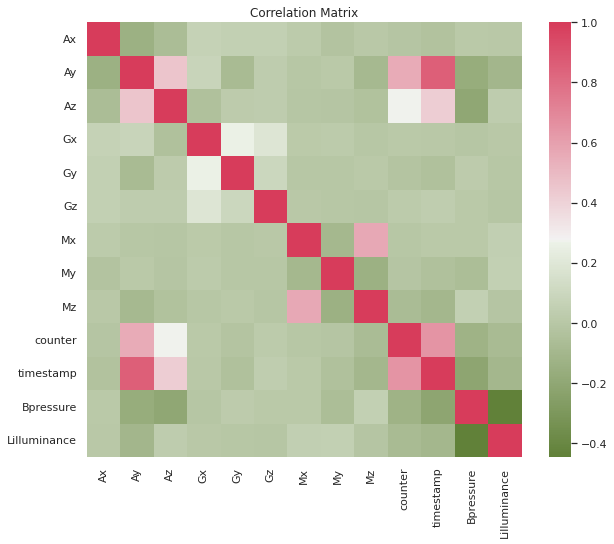

In [291]:
# Correlation matrix
CorrInfo = pd.DataFrame(df,columns=["Ax","Ay","Az","Gx","Gy","Gz","Mx","My","Mz","counter", "timestamp", 'Bpressure', 'Lilluminance'])

f, ax = plt.subplots(figsize=(10, 8))
corr = CorrInfo.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(110, 5, as_cmap=True),
            square=True, ax=ax)
plt.title("Correlation Matrix")

In [292]:
#Square root of sum of squares of accelerometer, linear acceleration and gyroscope data
df["AxMy"] = np.sqrt(np.square(df['Ax']) + np.square(df['My']))
df["AxGy"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gy']))
df["Ayz"] = np.sqrt(np.square(df['Ay']) + np.square(df['Az']))
df["AyGz"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gz']))
df["AzGx"] = np.sqrt(np.square(df['Az']) + np.square(df['Gx']))
df["Gzy"] = np.sqrt(np.square(df['Gz']) + np.square(df['Gy']) )
df["MxGy"] = np.sqrt(np.square(df['Mx']) + np.square(df['Gy']) )
df["MxGx"] = np.sqrt(np.square(df['Mx']) + np.square(df['Gx']) )
df["MyGy"] = np.sqrt(np.square(df['My']) + np.square(df['Gy']) )
df["MyGx"] = np.sqrt(np.square(df['My']) + np.square(df['Gx']) )
df["Myz"] = np.sqrt(np.square(df['My']) + np.square(df['Mz']))
df["Mxz"] = np.sqrt(np.square(df['Mx']) + np.square(df['Mz']))

In [293]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(df.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

activity        1.000000
Bpressure       0.703829
Lilluminance    0.574100
Az              0.099020
Myz             0.053774
Mxz             0.043046
AxMy            0.040550
MyGx            0.039747
MyGy            0.039540
Mx              0.038579
MxGy            0.025105
MxGx            0.024826
Mz              0.024479
Ayz             0.024321
Ay              0.022549
AxGy            0.021609
Gzy             0.020300
AyGz            0.018999
My              0.016216
Gy              0.016021
counter         0.011485
timestamp       0.008610
Gx              0.007923
AzGx            0.006968
Gz              0.004587
Ax              0.002685
Name: activity, dtype: float64


# Modelo de red neuronal

In [294]:
#Para ver la mayor corelación
features = ["Ayz", 'Ax', "Az", "AxMy", "AyGz", "AxGy", "AzGx", "MyGy", "MyGx", "Myz", "Mx", "Mxz", "MxGx", "MxGy", 'Mz']
X_orig = df[features]
y = df['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 53890
Número de columnas: 15


In [295]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = df[features]
y = df['activity']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
#model.add(LSTM(256, input_shape=(1, X_train.shape[2])))
#model.add(Dropout(0.2))
#model.add(Dense(6, activation='softmax'))
#--------------------------------------------
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))
model.add(LSTM(128))
#model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))
#--------------------------------------------
#model.add(LSTM(128, input_shape=(1, X_train.shape[2])))
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(LSTM(128))
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense
#model.add(Dense(6, activation='softmax'))
#------------------------------------------------
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la primera capa LSTM
#model.add(LSTM(128))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la segunda capa LSTM
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la otra capa Dense adicional
#model.add(Dense(6, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
2023-07-26 20:08:44.144133: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-07-26 20:08:44.145316: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype i

Epoch 1/20


2023-07-26 20:08:44.366523: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-07-26 20:08:44.369171: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-07-26 20:08:44.372343: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

670/674 [============================>.] - ETA: 0s - loss: 0.9053 - accuracy: 0.6133

2023-07-26 20:08:52.498465: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-07-26 20:08:52.499670: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-07-26 20:08:52.500657: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

674/674 [==============================] - 9s 9ms/step - loss: 0.9047 - accuracy: 0.6137 - val_loss: 0.8166 - val_accuracy: 0.6457
Epoch 2/20
674/674 [==============================] - 6s 9ms/step - loss: 0.7808 - accuracy: 0.6718 - val_loss: 0.7852 - val_accuracy: 0.6760
Epoch 3/20
674/674 [==============================] - 7s 10ms/step - loss: 0.7291 - accuracy: 0.6969 - val_loss: 0.7375 - val_accuracy: 0.6942
Epoch 4/20
674/674 [==============================] - 5s 8ms/step - loss: 0.6966 - accuracy: 0.7142 - val_loss: 0.7035 - val_accuracy: 0.7127
Epoch 5/20
674/674 [==============================] - 4s 6ms/step - loss: 0.6681 - accuracy: 0.7274 - val_loss: 0.6836 - val_accuracy: 0.7192
Epoch 6/20
674/674 [==============================] - 4s 6ms/step - loss: 0.6488 - accuracy: 0.7361 - val_loss: 0.6619 - val_accuracy: 0.7320
Epoch 7/20
674/674 [==============================] - 4s 6ms/step - loss: 0.6289 - accuracy: 0.7433 - val_loss: 0.6429 - val_accuracy: 0.7352
Epoch 8/20
674/6

In [296]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2023-07-26 20:10:24.962406: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-07-26 20:10:24.963802: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-07-26 20:10:24.964774: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

337/337 [==============================] - 1s 1ms/step
Accuracy: 0.7879940619781035
Precision: 0.7856025054331017
Recall: 0.7879940619781035
F1 Score: 0.7851290767723326


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

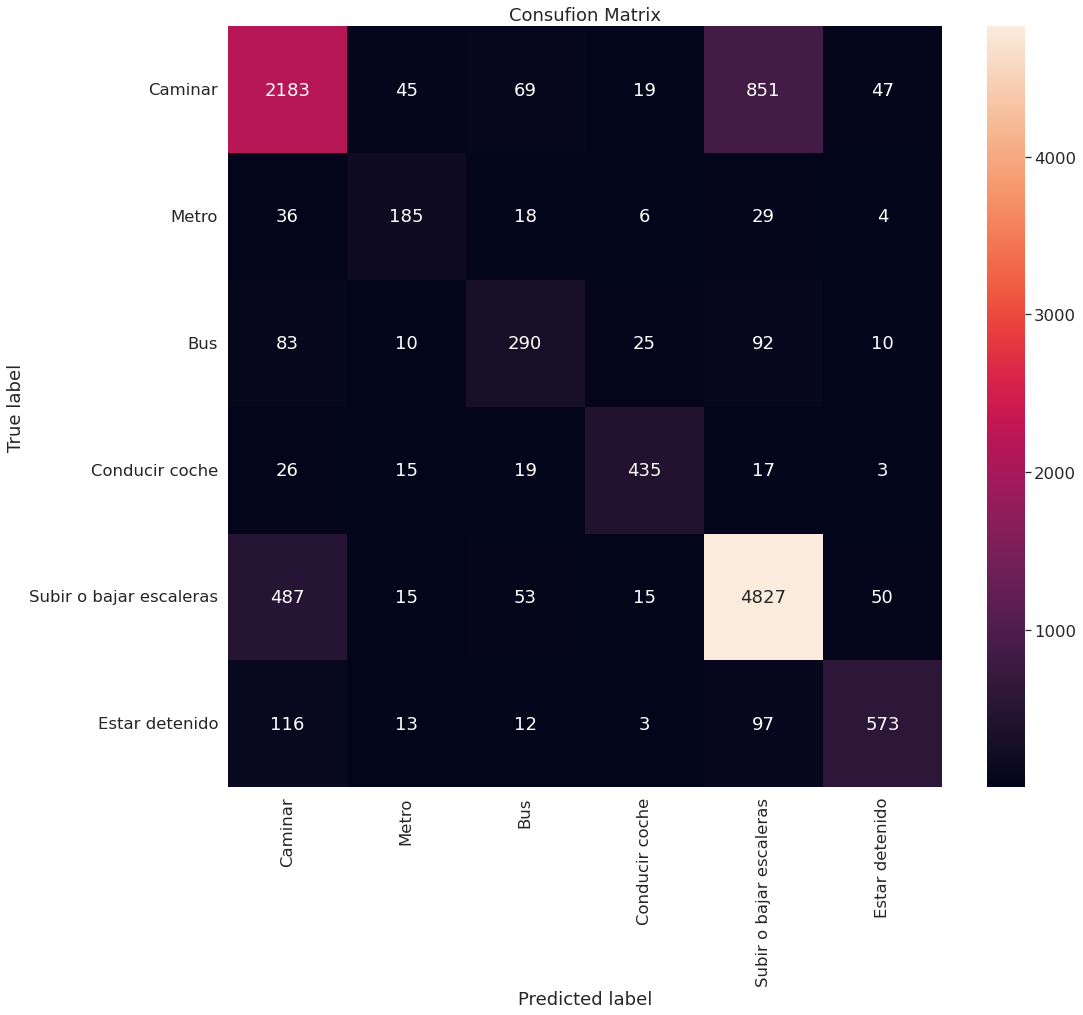

In [297]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

#Labels=['Caminar', 'Metro', 'Conducir coche', 'Subir o bajar escaleras']
#Labels=['Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
#Labels=['Metro', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [298]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

# Imprimir el resultado
for valor, conteo in zip(valores, conteos):
    print(f"Valor: {valor}, Cantidad: {conteo}")

Valor: 0, Cantidad: 3214
Valor: 1, Cantidad: 278
Valor: 2, Cantidad: 510
Valor: 3, Cantidad: 515
Valor: 4, Cantidad: 5447
Valor: 5, Cantidad: 814
